This notebook demonstrates a simple linear regression analysis using R to model Salary based on Years of Experience.

Read the dataset

In [1]:
dataset <- read.csv("regression_data.csv")

Fit a linear model

In [2]:
model <- lm(Salary ~ YearsExperience, data=dataset)

This cell calculates the slope, intercept and the correlation coefficient. Slope indicates how much salary changes for each additional year of experience. Intercept is the predicted salary when experience is zero.Correlation coefficient (r) measures the strength of the relationship.

In [3]:
slope <- coef(model)[2]
intercept <- coef(model)[1]
r <- cor(dataset$YearsExperience,dataset$Salary)
print(paste("Slope:", slope))
print(paste("Intercept:", intercept))
print(paste("Correlation coefficient (r):", r))

[1] "Slope: 8285.29209990353"
[1] "Intercept: 29203.5226712402"
[1] "Correlation coefficient (r): 0.886087798309884"


This cell calculates the Mean Squared Error (MSE). MSE measures prediction error.

In [4]:
mse <- mean(
  (predict(model) - dataset$Salary)^2
)
print(paste("MSE:", mse))

[1] "MSE: 17523844.0829028"


Plotting the data and the model

`geom_smooth()` using formula = 'y ~ x'


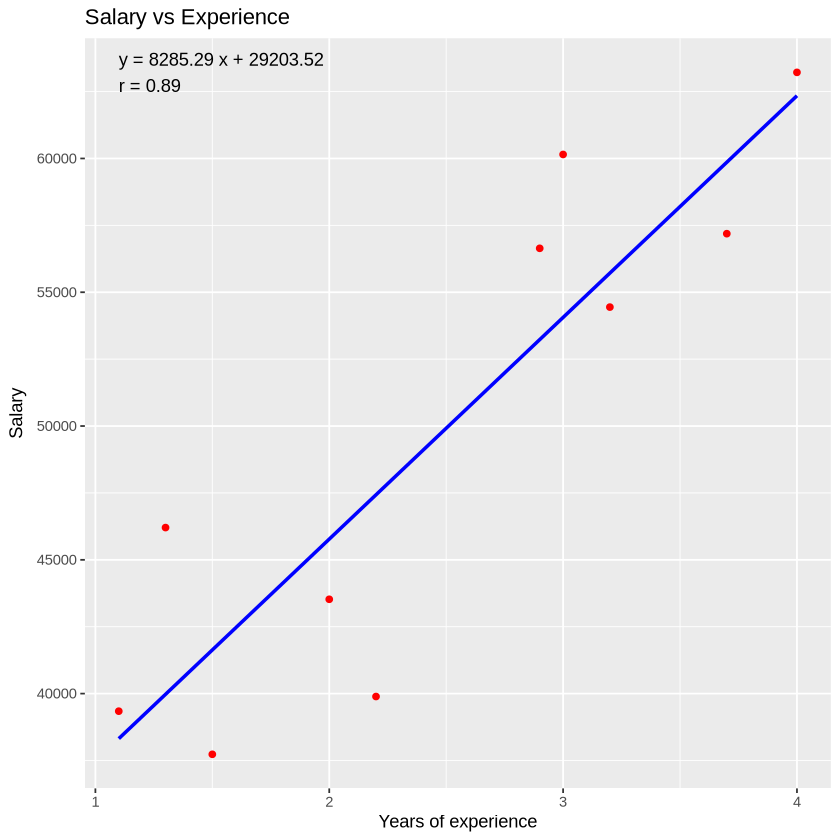

In [5]:
library(ggplot2)
ggplot(dataset, aes(x = YearsExperience, y = Salary)) +
  geom_point(color = "red") +
  geom_smooth(method = "lm", se = FALSE, color = "blue") +
  annotate("text", x = min(dataset$YearsExperience), y = max(dataset$Salary), hjust = 0, label = paste("y =", round(slope, 2), "x +", round(intercept, 2), "\nr =", round(r, 2)))+
  ggtitle('Salary vs Experience') +
  xlab('Years of experience') +
  ylab('Salary')

Model summary

In [6]:
summary(model)


Call:
lm(formula = Salary ~ YearsExperience, data = dataset)

Residuals:
    Min      1Q  Median      3Q     Max 
-7540.2 -2564.9  -199.1  2814.8  6230.6 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)        29204       4092   7.136 9.84e-05 ***
YearsExperience     8285       1532   5.407 0.000641 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4680 on 8 degrees of freedom
Multiple R-squared:  0.7852,	Adjusted R-squared:  0.7583 
F-statistic: 29.24 on 1 and 8 DF,  p-value: 0.0006407
